# Clasificación Multi-clase de Artículos de Noticias BBC con Transformers

Este notebook implementa un sistema de clasificación multi-clase para artículos de noticias de la BBC utilizando modelos transformer (BERT).

## Objetivo
Desarrollar un modelo de clasificación multi-clase basado en transformers que identifique la categoría de artículos de noticias de la BBC (Sport, Business, Politics, Tech, etc.)

## 1. Instalación de Dependencias

In [1]:
# Instalar las librerías necesarias
!pip install transformers torch datasets scikit-learn kagglehub pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip


## 2. Importación de Librerías

In [2]:
!pip install kagglehub


[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
!pip install seaborn


[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [4]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Transformers y PyTorch
import torch
from transformers import BertTokenizer, BertForSequenceClassification, AdamW, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader, random_split

# Scikit-learn para métricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Configurar dispositivo (GPU si está disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


## 3. Descarga y Carga del Dataset

In [5]:
# Descargar el dataset de BBC Articles
path = kagglehub.dataset_download("jacopoferretti/bbc-articles-dataset")
print(f"Dataset descargado en: {path}")

Dataset descargado en: /root/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/12


In [6]:
# Cargar el dataset
data_path = Path(path)
csv_files = list(data_path.rglob('*.csv'))
print(f"Archivos CSV encontrados: {csv_files}")

# Cargar el CSV principal
df = pd.read_csv(csv_files[0])
print(f"\nForma del dataset: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()

Archivos CSV encontrados: [PosixPath('/root/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/12/bbc_news_text_complexity_summarization.csv'), PosixPath('/root/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/12/archive/bbc_text_cls.csv'), PosixPath('/root/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/12/archive (2)/bbc-news-data.csv')]

Forma del dataset: (2127, 7)

Columnas: ['text', 'labels', 'no_sentences', 'Flesch Reading Ease Score', 'Dale-Chall Readability Score', 'text_rank_summary', 'lsa_summary']

Primeras filas:


,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...


In [7]:
# Análisis exploratorio de datos
print("Información del dataset:")
print(df.info())
print("\n" + "="*50)
print("Estadísticas descriptivas:")
print(df.describe())
print("\n" + "="*50)
print("Distribución de categorías:")
print(df['labels'].value_counts())
print("\n" + "="*50)
print(f"Número de categorías únicas: {df['labels'].nunique()}")
print(f"Categorías: {df['labels'].unique()}")

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2127 entries, 0 to 2126
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   text                          2127 non-null   object 
 1   labels                        2127 non-null   object 
 2   no_sentences                  2127 non-null   int64  
 3   Flesch Reading Ease Score     2127 non-null   float64
 4   Dale-Chall Readability Score  2127 non-null   float64
 5   text_rank_summary             2127 non-null   object 
 6   lsa_summary                   2127 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 116.4+ KB
None

Estadísticas descriptivas:
       no_sentences  Flesch Reading Ease Score  Dale-Chall Readability Score
count   2127.000000                2127.000000                   2127.000000
mean      18.968030                  63.645548                      9.145581
std       

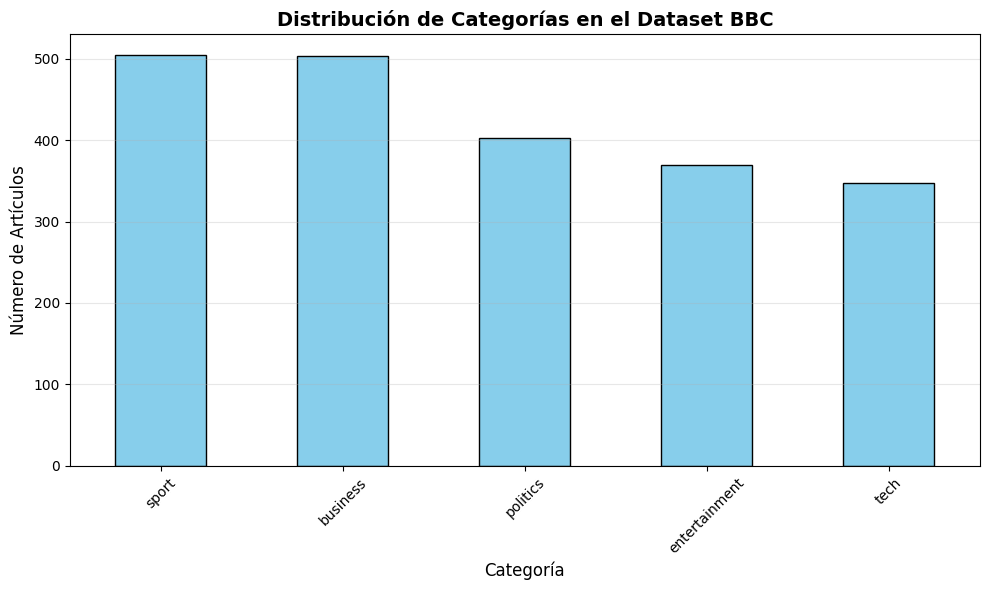

In [8]:
# Visualizar distribución de categorías
plt.figure(figsize=(10, 6))
df['labels'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribución de Categorías en el Dataset BBC', fontsize=14, fontweight='bold')
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Número de Artículos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Preprocesamiento del Texto

### 4.1 Limpieza y Preparación de Datos

En este paso creamos un pipeline para:
- Limpiar el texto (eliminar valores nulos, normalizar)
- Codificar las etiquetas categóricas
- Preparar el formato adecuado para el modelo BERT

In [9]:
# Preprocesamiento de datos
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# Eliminar filas con valores nulos
df = df.dropna()



# Crear mapeo de categorías a números (para clasificación multi-clase)
category_to_id = {cat: idx for idx, cat in enumerate(df['labels'].unique())}
id_to_category = {idx: cat for cat, idx in category_to_id.items()}

df['label'] = df['labels'].map(category_to_id)

print(f"\nMapeo de categorías:")
for cat, idx in category_to_id.items():
    print(f"  {cat}: {idx}")

print(f"\nNúmero de clases: {len(category_to_id)}")
print(f"Forma del dataset preprocesado: {df.shape}")

Valores nulos por columna:
text                            0
labels                          0
no_sentences                    0
Flesch Reading Ease Score       0
Dale-Chall Readability Score    0
text_rank_summary               0
lsa_summary                     0
dtype: int64

Mapeo de categorías:
  business: 0
  entertainment: 1
  politics: 2
  sport: 3
  tech: 4

Número de clases: 5
Forma del dataset preprocesado: (2127, 8)


### 4.2 Tokenización con BERT

Utilizamos el tokenizador de BERT para convertir el texto en secuencias de tokens que el modelo puede procesar.

In [10]:
# Cargar el tokenizador de BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Parámetros de tokenización
MAX_LENGTH = 512  # Longitud máxima de secuencia para BERT

# Clase personalizada para el dataset
class BBCDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenizar el texto
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("Clase BBCDataset creada exitosamente")

Clase BBCDataset creada exitosamente


### 4.3 División del Dataset

Dividimos el dataset en conjuntos de entrenamiento (70%), validación (15%) y prueba (15%).

In [11]:
# Dividir el dataset en entrenamiento, validación y prueba
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'].values, 
    df['label'].values, 
    test_size=0.3, 
    random_state=42,
    stratify=df['label'].values
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, 
    temp_labels, 
    test_size=0.5, 
    random_state=42,
    stratify=temp_labels
)

print(f"Tamaño del conjunto de entrenamiento: {len(train_texts)}")
print(f"Tamaño del conjunto de validación: {len(val_texts)}")
print(f"Tamaño del conjunto de prueba: {len(test_texts)}")

# Crear datasets
train_dataset = BBCDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset = BBCDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)
test_dataset = BBCDataset(test_texts, test_labels, tokenizer, MAX_LENGTH)

# Crear DataLoaders
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nNúmero de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(val_loader)}")
print(f"Número de batches de prueba: {len(test_loader)}")

Tamaño del conjunto de entrenamiento: 1488
Tamaño del conjunto de validación: 319
Tamaño del conjunto de prueba: 320

Número de batches de entrenamiento: 93
Número de batches de validación: 20
Número de batches de prueba: 20


## 5. Implementación de la Arquitectura de Transformers

### 5.1 Justificación del Modelo

**Modelo seleccionado:** BERT (Bidirectional Encoder Representations from Transformers)

**Justificación:**
- **Comprensión bidireccional:** BERT procesa el texto en ambas direcciones, capturando mejor el contexto de las palabras.
- **Pre-entrenamiento:** Ya está entrenado en grandes corpus, lo que proporciona representaciones semánticas ricas.
- **Adaptabilidad:** Fácilmente adaptable para clasificación multi-clase mediante fine-tuning.

**Capa de clasificación:**
- Utilizamos `BertForSequenceClassification` que añade una capa densa con activación softmax para clasificación multi-clase.
- La capa de salida tiene tantas neuronas como categorías (5 en nuestro caso).
- Softmax convierte las salidas en probabilidades para cada clase.

In [12]:
# Cargar el modelo BERT para clasificación de secuencias
num_labels = len(category_to_id)

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels,
    output_attentions=False,
    output_hidden_states=False,
)

# Mover el modelo al dispositivo (GPU/CPU)
model = model.to(device)

print(f"Modelo BERT cargado con {num_labels} clases de salida")
print(f"Modelo en dispositivo: {next(model.parameters()).device}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Modelo BERT cargado con 5 clases de salida
Modelo en dispositivo: cuda:0


## 6. Entrenamiento y Evaluación del Modelo

### 6.1 Configuración del Entrenamiento

In [13]:
# Configuración del entrenamiento
EPOCHS = 3  # Entrenar entre 2-5 épocas según recursos
LEARNING_RATE = 2e-5

# Optimizador AdamW (optimizado para transformers)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, eps=1e-8)

# Scheduler para ajustar la tasa de aprendizaje
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print(f"Configuración de entrenamiento:")
print(f"  Épocas: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Total steps: {total_steps}")
print(f"  Batch size: {BATCH_SIZE}")

Configuración de entrenamiento:
  Épocas: 3
  Learning rate: 2e-05
  Total steps: 279
  Batch size: 16


In [14]:
# Función de entrenamiento
def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    losses = []
    correct_predictions = 0
    total_predictions = 0
    
    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        # Calcular accuracy
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        total_predictions += labels.size(0)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        losses.append(loss.item())
    
    return np.mean(losses), correct_predictions.double() / total_predictions

# Función de evaluación
def eval_model(model, data_loader, device):
    model.eval()
    losses = []
    correct_predictions = 0
    total_predictions = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            total_predictions += labels.size(0)
            
            losses.append(loss.item())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.mean(losses), correct_predictions.double() / total_predictions, all_preds, all_labels

print("Funciones de entrenamiento y evaluación definidas")

Funciones de entrenamiento y evaluación definidas


### 6.2 Entrenamiento del Modelo

In [15]:
# Entrenamiento del modelo
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("Iniciando entrenamiento...")
print("="*70)

for epoch in range(EPOCHS):
    print(f'\nÉpoca {epoch + 1}/{EPOCHS}')
    print('-' * 70)
    
    # Entrenamiento
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    
    # Validación
    val_loss, val_acc, _, _ = eval_model(model, val_loader, device)
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')
    
    # Guardar métricas
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc.item())
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc.item())

print("\n" + "="*70)
print("Entrenamiento completado")

Iniciando entrenamiento...

Época 1/3
----------------------------------------------------------------------
Train Loss: 0.7086 | Train Acc: 0.8468
Val Loss: 0.1910 | Val Acc: 0.9718

Época 2/3
----------------------------------------------------------------------
Train Loss: 0.0843 | Train Acc: 0.9872
Val Loss: 0.0968 | Val Acc: 0.9749

Época 3/3
----------------------------------------------------------------------
Train Loss: 0.0297 | Train Acc: 0.9953
Val Loss: 0.0933 | Val Acc: 0.9843

Entrenamiento completado


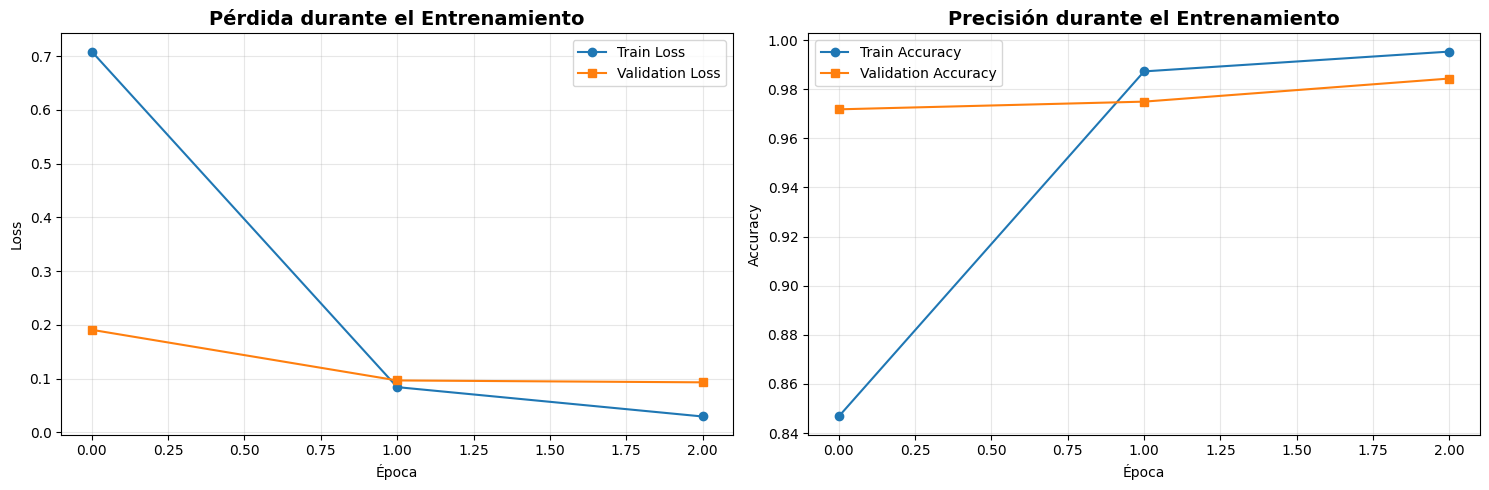

In [16]:
# Visualizar el progreso del entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Validation Loss', marker='s')
ax1.set_title('Pérdida durante el Entrenamiento', fontsize=14, fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['val_acc'], label='Validation Accuracy', marker='s')
ax2.set_title('Precisión durante el Entrenamiento', fontsize=14, fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Evaluación en el Conjunto de Prueba

In [17]:
# Evaluar en el conjunto de prueba
test_loss, test_acc, test_preds, test_true = eval_model(model, test_loader, device)

print("="*70)
print("RESULTADOS EN EL CONJUNTO DE PRUEBA")
print("="*70)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print("="*70)

RESULTADOS EN EL CONJUNTO DE PRUEBA
Test Loss: 0.0623
Test Accuracy: 0.9875


### 6.4 Métricas Detalladas por Categoría

In [18]:
# Reporte de clasificación detallado
category_names = [id_to_category[i] for i in range(num_labels)]

print("\nREPORTE DE CLASIFICACIÓN DETALLADO")
print("="*70)
print(classification_report(
    test_true, 
    test_preds, 
    target_names=category_names,
    digits=4
))

# Calcular métricas por clase
precision, recall, f1, support = precision_recall_fscore_support(
    test_true, 
    test_preds, 
    average=None,
    labels=range(num_labels)
)

# Crear DataFrame con métricas por categoría
metrics_df = pd.DataFrame({
    'Categoría': category_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

metrics_df = metrics_df.sort_values('F1-Score', ascending=False)
print("\nMÉTRICAS POR CATEGORÍA (Ordenadas por F1-Score)")
print("="*70)
print(metrics_df.to_string(index=False))

# Identificar mejor y peor categoría
best_category = metrics_df.iloc[0]
worst_category = metrics_df.iloc[-1]

print("\n" + "="*70)
print("ANÁLISIS DE RENDIMIENTO")
print("="*70)
print(f"\n MEJOR RENDIMIENTO:")
print(f"  Categoría: {best_category['Categoría']}")
print(f"  F1-Score: {best_category['F1-Score']:.4f}")
print(f"  Precision: {best_category['Precision']:.4f}")
print(f"  Recall: {best_category['Recall']:.4f}")

print(f"\n PEOR RENDIMIENTO:")
print(f"  Categoría: {worst_category['Categoría']}")
print(f"  F1-Score: {worst_category['F1-Score']:.4f}")
print(f"  Precision: {worst_category['Precision']:.4f}")
print(f"  Recall: {worst_category['Recall']:.4f}")
print("="*70)


REPORTE DE CLASIFICACIÓN DETALLADO
               precision    recall  f1-score   support

     business     0.9867    0.9737    0.9801        76
entertainment     0.9821    1.0000    0.9910        55
     politics     0.9677    0.9836    0.9756        61
        sport     1.0000    1.0000    1.0000        76
         tech     1.0000    0.9808    0.9903        52

     accuracy                         0.9875       320
    macro avg     0.9873    0.9876    0.9874       320
 weighted avg     0.9876    0.9875    0.9875       320


MÉTRICAS POR CATEGORÍA (Ordenadas por F1-Score)
    Categoría  Precision   Recall  F1-Score  Support
        sport   1.000000 1.000000  1.000000       76
entertainment   0.982143 1.000000  0.990991       55
         tech   1.000000 0.980769  0.990291       52
     business   0.986667 0.973684  0.980132       76
     politics   0.967742 0.983607  0.975610       61

ANÁLISIS DE RENDIMIENTO

 MEJOR RENDIMIENTO:
  Categoría: sport
  F1-Score: 1.0000
  Precision: 1.

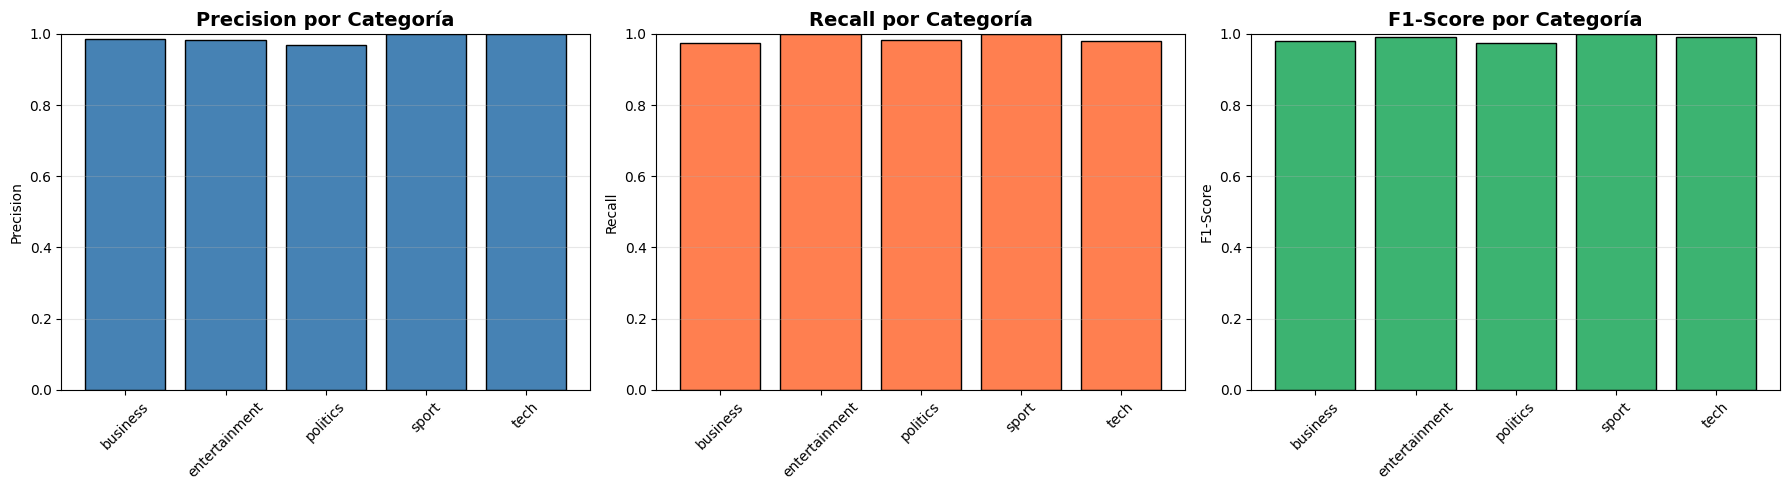

In [19]:
# Visualización de métricas por categoría
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_plot = metrics_df.sort_values('Categoría')

# Precision
axes[0].bar(metrics_plot['Categoría'], metrics_plot['Precision'], color='steelblue', edgecolor='black')
axes[0].set_title('Precision por Categoría', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Precision')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Recall
axes[1].bar(metrics_plot['Categoría'], metrics_plot['Recall'], color='coral', edgecolor='black')
axes[1].set_title('Recall por Categoría', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# F1-Score
axes[2].bar(metrics_plot['Categoría'], metrics_plot['F1-Score'], color='mediumseagreen', edgecolor='black')
axes[2].set_title('F1-Score por Categoría', fontsize=14, fontweight='bold')
axes[2].set_ylabel('F1-Score')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.5 Matriz de Confusión

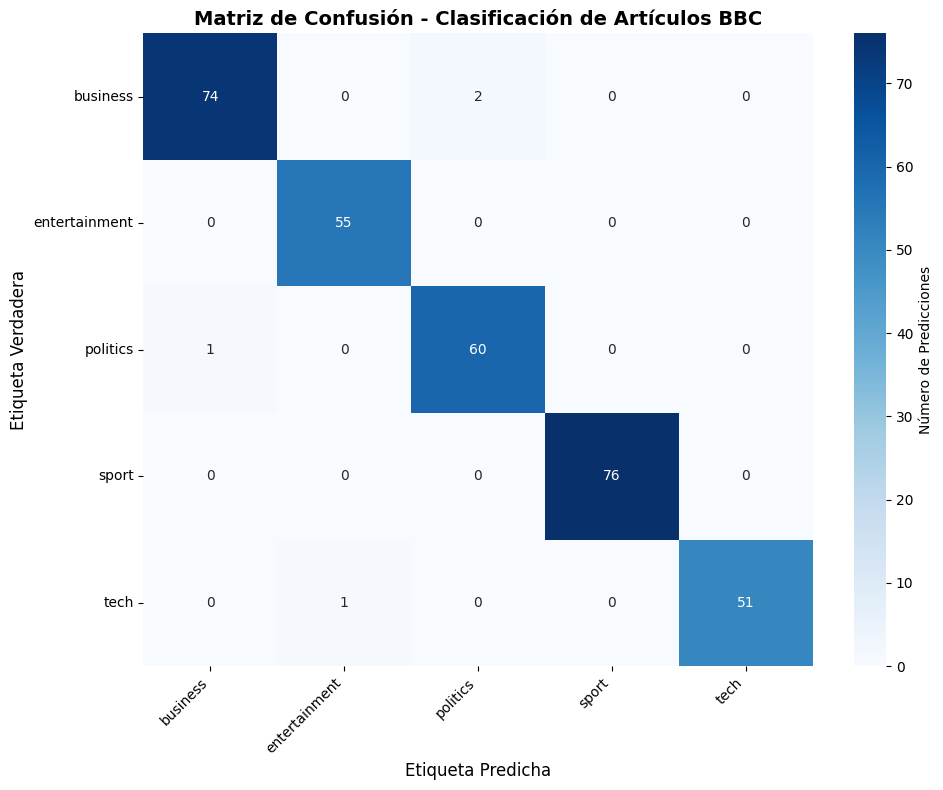


ANÁLISIS DE LA MATRIZ DE CONFUSIÓN
business     - Correctas:  74/ 76 (97.37%)
entertainment - Correctas:  55/ 55 (100.00%)
politics     - Correctas:  60/ 61 (98.36%)
sport        - Correctas:  76/ 76 (100.00%)
tech         - Correctas:  51/ 52 (98.08%)


In [20]:
# Matriz de confusión
cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=category_names, 
            yticklabels=category_names,
            cbar_kws={'label': 'Número de Predicciones'})
plt.title('Matriz de Confusión - Clasificación de Artículos BBC', fontsize=14, fontweight='bold')
plt.ylabel('Etiqueta Verdadera', fontsize=12)
plt.xlabel('Etiqueta Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Análisis de la matriz de confusión
print("\nANÁLISIS DE LA MATRIZ DE CONFUSIÓN")
print("="*70)
for i, cat in enumerate(category_names):
    total = cm[i].sum()
    correct = cm[i][i]
    accuracy = correct / total if total > 0 else 0
    print(f"{cat:12} - Correctas: {correct:3}/{total:3} ({accuracy:6.2%})")

## 7. Predicción en Ejemplos Nuevos

In [21]:
# Función para predecir categoría de un texto nuevo
def predict_category(text, model, tokenizer, device, max_length=512):
    model.eval()
    
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        return_token_type_ids=False,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1)
    
    return pred.item(), probs.cpu().numpy()[0]

# Probar con algunos ejemplos del conjunto de prueba
print("EJEMPLOS DE PREDICCIONES")
print("="*70)

num_examples = 30
random_indices = np.random.choice(len(test_texts), num_examples, replace=False)

for idx in random_indices:
    text_sample = test_texts[idx][:200] + "..."  # Mostrar solo los primeros 200 caracteres
    true_label = test_labels[idx]
    
    pred_label, probabilities = predict_category(test_texts[idx], model, tokenizer, device)
    
    print(f"\nTexto: {text_sample}")
    print(f"Categoría Real: {id_to_category[true_label]}")
    print(f"Categoría Predicha: {id_to_category[pred_label]}")
    print(f"Confianza: {probabilities[pred_label]:.4f}")
    
    # Mostrar top 3 probabilidades
    top_3_indices = np.argsort(probabilities)[-3:][::-1]
    print("Top 3 probabilidades:")
    for i in top_3_indices:
        print(f"  {id_to_category[i]}: {probabilities[i]:.4f}")
    print("-" * 70)

EJEMPLOS DE PREDICCIONES

Texto: Asian quake hits European shares

Shares in Europe's leading reinsurers and travel firms have fallen as the scale of the damage wrought by tsunamis across south Asia has become apparent.

More than 23...
Categoría Real: business
Categoría Predicha: business
Confianza: 0.9905
Top 3 probabilidades:
  business: 0.9905
  politics: 0.0032
  tech: 0.0026
----------------------------------------------------------------------

Texto: Mayor will not retract Nazi jibe

London mayor Ken Livingstone has again refused to retract a Nazi insult made to a Jewish reporter.

Labour's Mr Livingstone, who says he is "standing by" his remarks,...
Categoría Real: politics
Categoría Predicha: politics
Confianza: 0.9876
Top 3 probabilidades:
  politics: 0.9876
  business: 0.0038
  sport: 0.0034
----------------------------------------------------------------------

Texto: Falconer rebuts 'charade' claims

Concessions on a bill which critics claim would allow euthanasia "throug

In [22]:
# Guardar el modelo entrenado
model_path = './bbc_classifier_model'
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)
print(f"Modelo guardado en: {model_path}")

# Para cargar el modelo:
# from transformers import BertForSequenceClassification, BertTokenizer
# loaded_model = BertForSequenceClassification.from_pretrained(model_path)
# loaded_tokenizer = BertTokenizer.from_pretrained(model_path)


Modelo guardado en: ./bbc_classifier_model
